# 🩺 MediSense AI — Complete Analysis Notebook
**Author:** Shubham Jaiswal | **Date:** June 2025 | **Version:** v2.0

---
This notebook covers the full ML pipeline:
1. Dataset Loading & EDA
2. Disease Distribution
3. Symptom Frequency Analysis
4. Symptom Severity Weights
5. Model Training & Cross-Validation
6. Model Comparison
7. Feature Importance (Explainable AI)
8. Severity Scoring Validation
9. Per-Class Accuracy Analysis
10. Key Findings & Summary


In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

# Navigate to project root regardless of where notebook is opened
BASE = os.getcwd()
if os.path.basename(BASE) == "notebooks":
    BASE = os.path.dirname(BASE)
sys.path.insert(0, BASE)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"]  = 110

BLUE  = "#1d4ed8"
TEAL  = "#06b6d4"
PURP  = "#8b5cf6"
GREEN = "#10b981"
RED   = "#ef4444"

os.makedirs(os.path.join(BASE, "images"), exist_ok=True)
print("Imports complete")
print(f"Project root: {BASE}")


Imports complete
Project root: c:\Users\SHUBHAM\Downloads\MediSense


---
## 1. 📂 Dataset Loading & Overview

In [2]:
df      = pd.read_csv(os.path.join(BASE, "data", "symptoms_dataset.csv"))
df_bin  = pd.read_csv(os.path.join(BASE, "data", "symptoms_binary.csv"))
df_desc = pd.read_csv(os.path.join(BASE, "data", "disease_description.csv"))
df_sev  = pd.read_csv(os.path.join(BASE, "data", "symptom_severity.csv"))
df_prec = pd.read_csv(os.path.join(BASE, "data", "precautions.csv"))
df_diet = pd.read_csv(os.path.join(BASE, "data", "diets.csv"))

print("Datasets loaded:")
for name, d in [("symptoms_dataset", df), ("symptoms_binary", df_bin),
                ("disease_description", df_desc), ("symptom_severity", df_sev),
                ("precautions", df_prec), ("diets", df_diet)]:
    print(f"  {name:25s}: {d.shape}")
df.head(3)


Datasets loaded:
  symptoms_dataset         : (4920, 18)
  symptoms_binary          : (4920, 133)
  disease_description      : (41, 7)
  symptom_severity         : (132, 2)
  precautions              : (41, 5)
  diets                    : (41, 5)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,skin_rash,dischromic_patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,dischromic_patches,itching,yellow_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Basic info:")
print(f"  Total samples   : {len(df_bin):,}")
print(f"  Total features  : {df_bin.shape[1]-1}")
print(f"  Diseases covered: {df_bin['Disease'].nunique()}")
print(f"  Samples/disease : {len(df_bin)//df_bin['Disease'].nunique()}")
print(f"  Missing values  : {df_bin.isnull().sum().sum()}")
print()
print("Disease class balance (first 10):")
print(df_bin["Disease"].value_counts().head(10))


Basic info:
  Total samples   : 4,920
  Total features  : 132
  Diseases covered: 41
  Samples/disease : 120
  Missing values  : 0

Disease class balance (first 10):
Disease
Fungal infection        120
Allergy                 120
GERD                    120
Chronic cholestasis     120
Drug Reaction           120
Peptic ulcer disease    120
AIDS                    120
Diabetes                120
Gastroenteritis         120
Bronchial Asthma        120
Name: count, dtype: int64


---
## 2. 📊 Disease Distribution

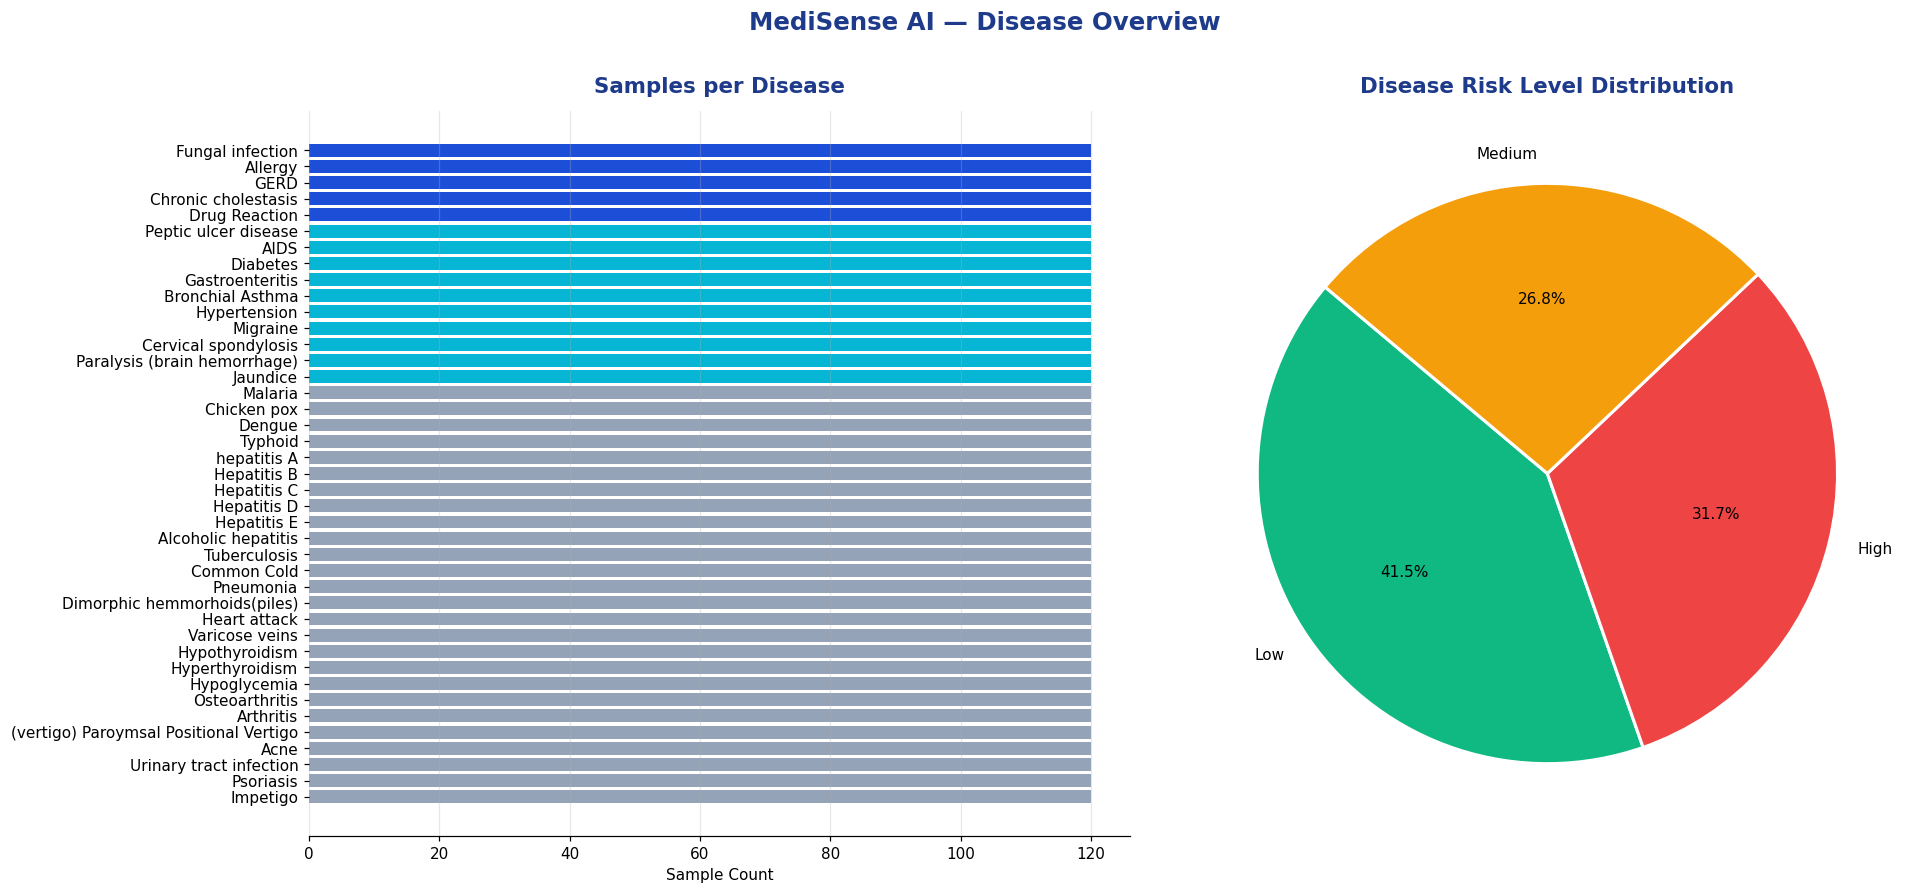

Saved: images/disease_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Disease sample counts
disease_counts = df_bin["Disease"].value_counts()
bar_colors = [BLUE if i < 5 else TEAL if i < 15 else "#94a3b8" for i in range(len(disease_counts))]
axes[0].barh(disease_counts.index[::-1], disease_counts.values[::-1], color=bar_colors[::-1], edgecolor="none")
axes[0].set_title("Samples per Disease", fontsize=14, fontweight="bold", color="#1e3a8a", pad=12)
axes[0].set_xlabel("Sample Count")
axes[0].grid(axis="x", alpha=0.3)
axes[0].spines[["top","right","left"]].set_visible(False)

# Risk level pie
risk_counts = df_desc["Risk_Level"].value_counts()
wcolors = {"High": RED, "Medium": "#f59e0b", "Low": GREEN}
axes[1].pie(risk_counts.values, labels=risk_counts.index,
            autopct="%1.1f%%",
            colors=[wcolors.get(r, BLUE) for r in risk_counts.index],
            startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Disease Risk Level Distribution", fontsize=14, fontweight="bold", color="#1e3a8a", pad=12)

plt.suptitle("MediSense AI — Disease Overview", fontsize=16, fontweight="bold", y=1.01, color="#1e3a8a")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "disease_distribution.png"), bbox_inches="tight", dpi=130)
plt.show()
print("Saved: images/disease_distribution.png")


---
## 3. 🤒 Symptom Frequency Analysis

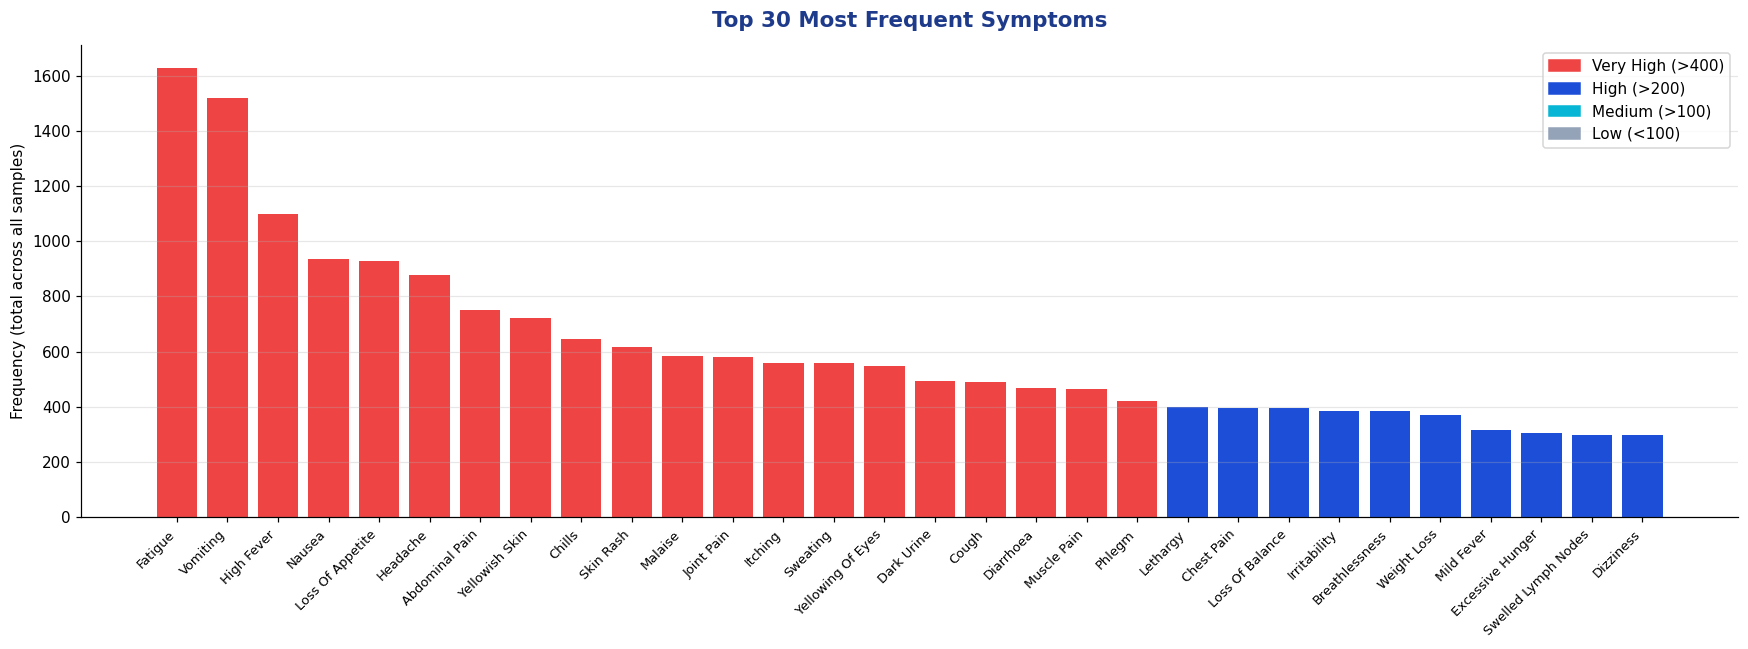

Top 5 most common symptoms:
  Fatigue                            : 1,628
  Vomiting                           : 1,517
  High Fever                         : 1,099
  Nausea                             : 936
  Loss Of Appetite                   : 927


In [5]:
sym_cols = [c for c in df_bin.columns if c != "Disease"]
sym_freq = df_bin[sym_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
top30 = sym_freq.head(30)
bar_colors = [RED if v > 400 else BLUE if v > 200 else TEAL if v > 100 else "#94a3b8" for v in top30.values]
ax.bar(range(len(top30)), top30.values, color=bar_colors, edgecolor="none")
ax.set_xticks(range(len(top30)))
ax.set_xticklabels([s.replace("_", " ").title() for s in top30.index],
                   rotation=45, ha="right", fontsize=8.5)
ax.set_title("Top 30 Most Frequent Symptoms", fontsize=14, fontweight="bold", color="#1e3a8a", pad=12)
ax.set_ylabel("Frequency (total across all samples)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

patches = [mpatches.Patch(color=RED,  label="Very High (>400)"),
           mpatches.Patch(color=BLUE, label="High (>200)"),
           mpatches.Patch(color=TEAL, label="Medium (>100)"),
           mpatches.Patch(color="#94a3b8", label="Low (<100)")]
ax.legend(handles=patches, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "symptom_frequency.png"), bbox_inches="tight", dpi=130)
plt.show()
print("Top 5 most common symptoms:")
for s, v in top30.head(5).items():
    print(f"  {s.replace('_',' ').title():35s}: {v:,}")


---
## 4. 🌡️ Symptom Severity Weights

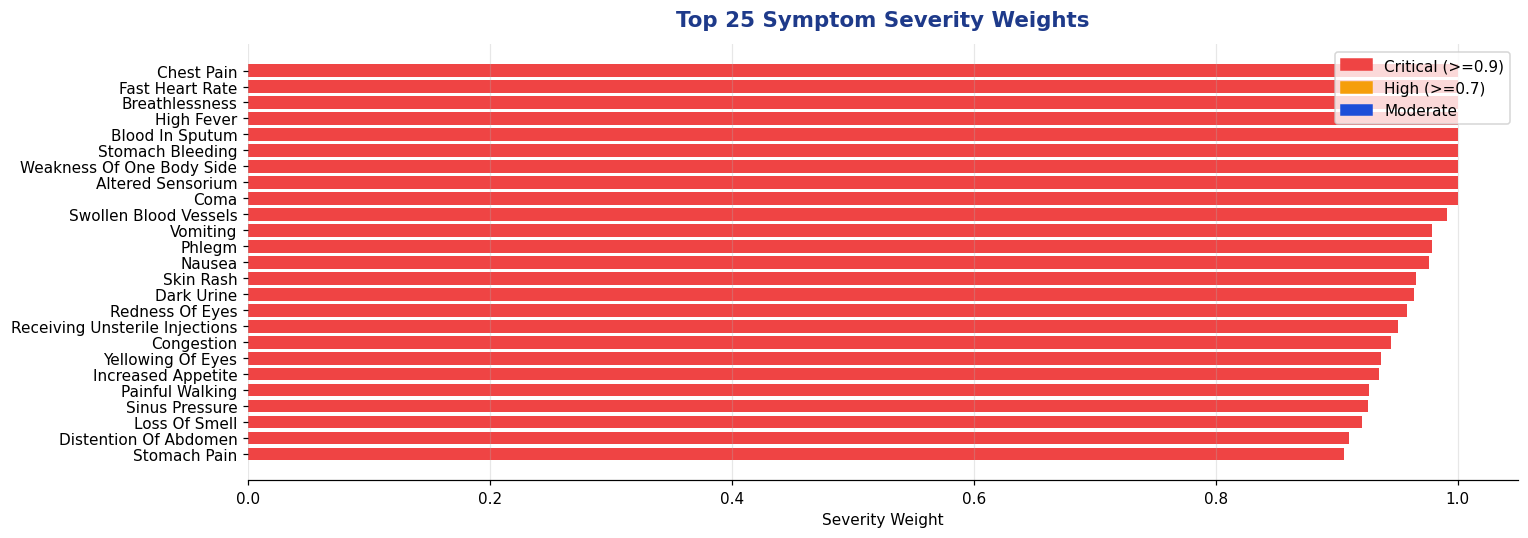

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
top25 = df_sev.head(25)
bar_colors = [RED if w >= 0.9 else "#f59e0b" if w >= 0.7 else BLUE for w in top25["weight"]]
ax.barh(top25["Symptom"][::-1].str.replace("_", " ").str.title(),
        top25["weight"][::-1], color=bar_colors[::-1], edgecolor="none")
ax.set_title("Top 25 Symptom Severity Weights", fontsize=14, fontweight="bold", color="#1e3a8a", pad=12)
ax.set_xlabel("Severity Weight")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right","left"]].set_visible(False)
patches = [mpatches.Patch(color=RED, label="Critical (>=0.9)"),
           mpatches.Patch(color="#f59e0b", label="High (>=0.7)"),
           mpatches.Patch(color=BLUE, label="Moderate")]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "symptom_severity.png"), bbox_inches="tight", dpi=130)
plt.show()


---
## 5. 🗺️ Disease × Symptom Heatmap

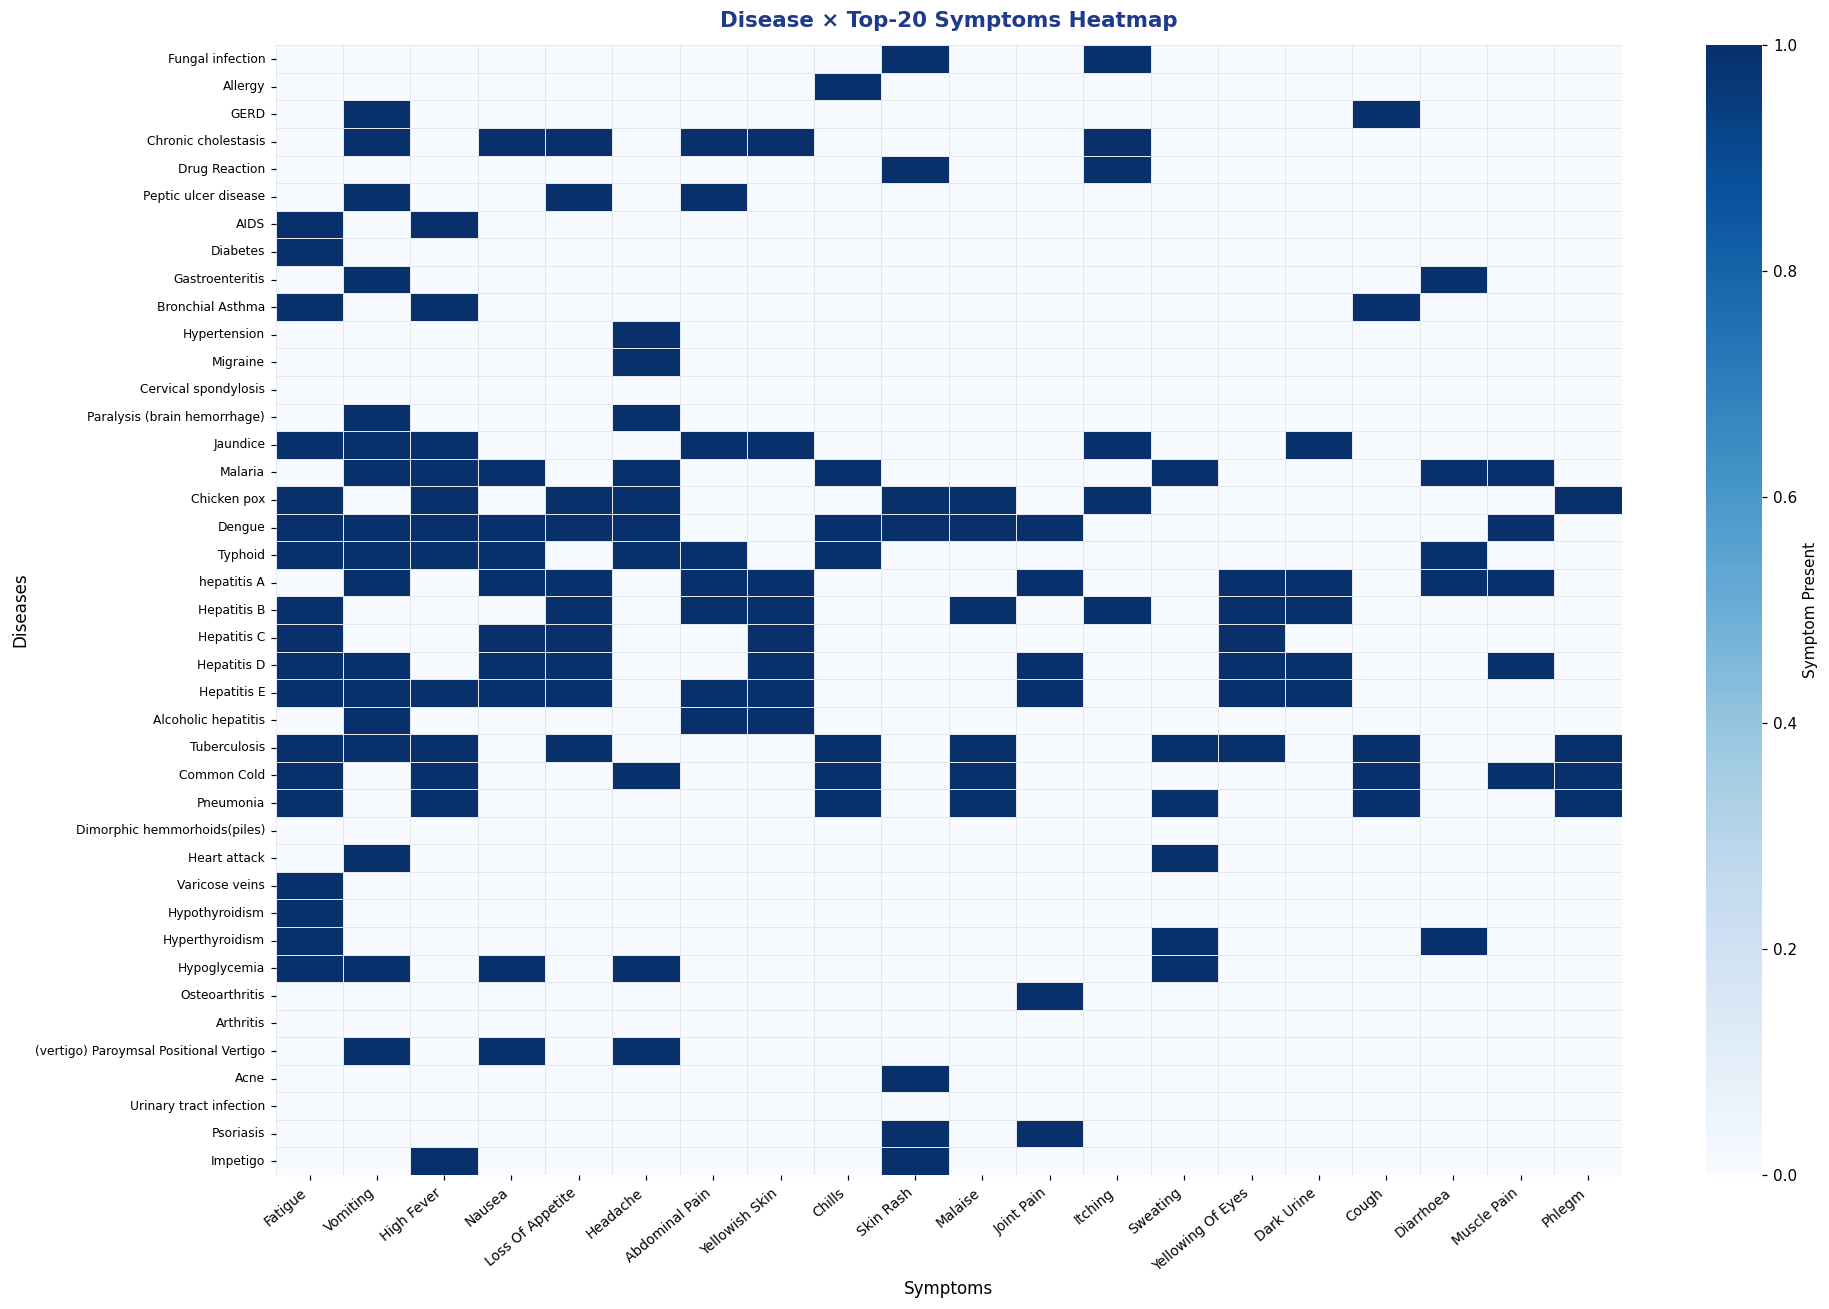

Saved: images/disease_symptom_heatmap.png


In [7]:
from utils.constants import DISEASE_SYMPTOMS, DISEASES

top_syms = sym_freq.head(20).index.tolist()
heat_data = []
for disease in DISEASES:
    known = set(DISEASE_SYMPTOMS.get(disease, []))
    heat_data.append([1 if s in known else 0 for s in top_syms])

heat_df = pd.DataFrame(heat_data, index=DISEASES,
                       columns=[s.replace("_"," ").title() for s in top_syms])

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(heat_df, ax=ax, cmap="Blues", linewidths=0.4, linecolor="#e5e7eb",
            cbar_kws={"label": "Symptom Present"}, square=False)
ax.set_title("Disease × Top-20 Symptoms Heatmap", fontsize=14, fontweight="bold", color="#1e3a8a", pad=12)
ax.set_xlabel("Symptoms", fontsize=11)
ax.set_ylabel("Diseases", fontsize=11)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "disease_symptom_heatmap.png"), bbox_inches="tight", dpi=130)
plt.show()
print("Saved: images/disease_symptom_heatmap.png")


---
## 6. 🤖 Model Training & Cross-Validation

In [8]:
X = df_bin[[c for c in df_bin.columns if c != "Disease"]]
y = df_bin["Disease"]
le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {X.shape[1]}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "SVC":          SVC(probability=True, kernel="rbf", C=1.0, random_state=42),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y_enc, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    cv_results[name] = {"mean": scores.mean(), "std": scores.std(), "test": test_acc, "scores": scores}
    print(f"  {name:20s}  CV={scores.mean()*100:.2f}% +/-{scores.std()*100:.2f}%   Test={test_acc*100:.2f}%")

best_name = max(cv_results, key=lambda k: cv_results[k]["mean"])
best_model = models[best_name]
print(f"Best model: {best_name}")


Train: 3,936 | Test: 984 | Features: 132
  RandomForest          CV=98.60% +/-0.47%   Test=98.68%
  SVC                   CV=99.72% +/-0.17%   Test=99.80%
Best model: SVC


---
## 7. 📊 Model Comparison Visualization

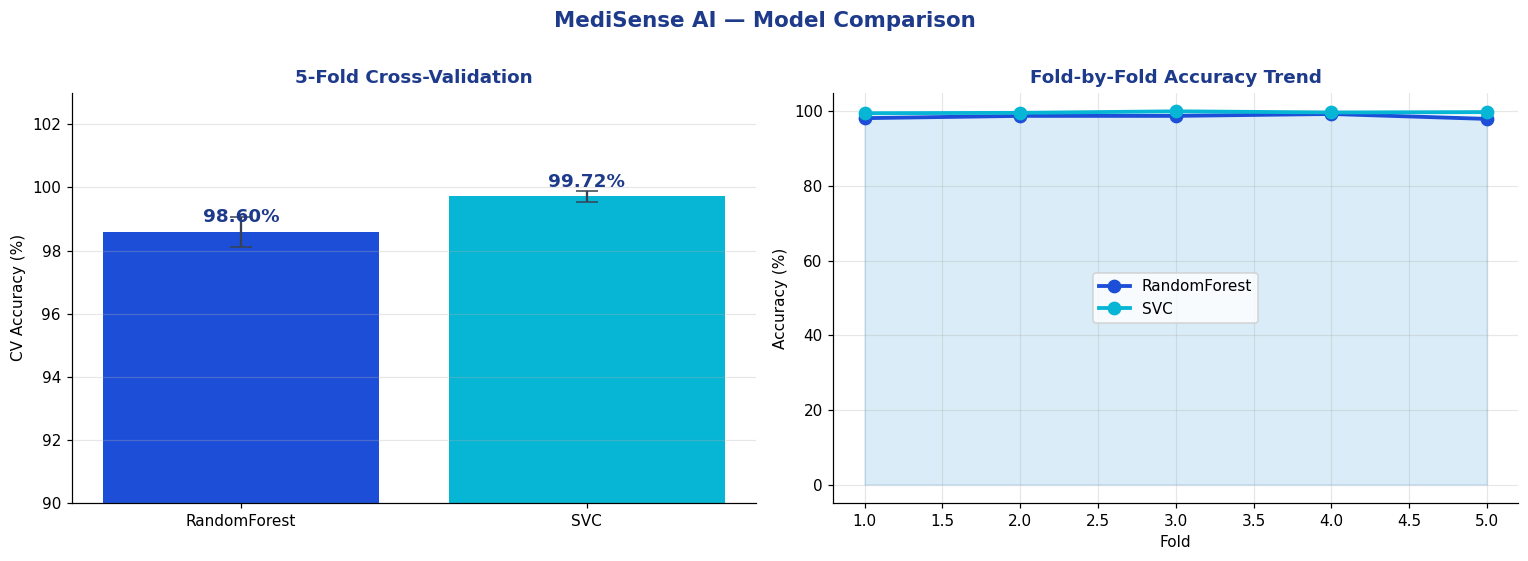

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names  = list(cv_results.keys())
means  = [cv_results[n]["mean"]*100 for n in names]
stds   = [cv_results[n]["std"]*100  for n in names]
colors = [BLUE, TEAL]

bars = axes[0].bar(names, means, yerr=stds, capsize=7,
                   color=colors, edgecolor="none",
                   error_kw={"ecolor": "#374151", "linewidth": 1.5})
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{m:.2f}%", ha="center", fontsize=12, fontweight="bold", color="#1e3a8a")
axes[0].set_ylim(90, 103)
axes[0].set_ylabel("CV Accuracy (%)")
axes[0].set_title("5-Fold Cross-Validation", fontweight="bold", color="#1e3a8a")
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

for i, n in enumerate(names):
    folds = cv_results[n]["scores"]*100
    axes[1].plot(range(1,6), folds, marker="o", linewidth=2.5,
                 color=colors[i], label=n, markersize=8)
    axes[1].fill_between(range(1,6), folds, alpha=0.08, color=colors[i])
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Fold-by-Fold Accuracy Trend", fontweight="bold", color="#1e3a8a")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("MediSense AI — Model Comparison", fontsize=14, fontweight="bold", color="#1e3a8a", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "model_comparison.png"), bbox_inches="tight", dpi=130)
plt.show()


---
## 8. 🔍 Feature Importance (Explainable AI)

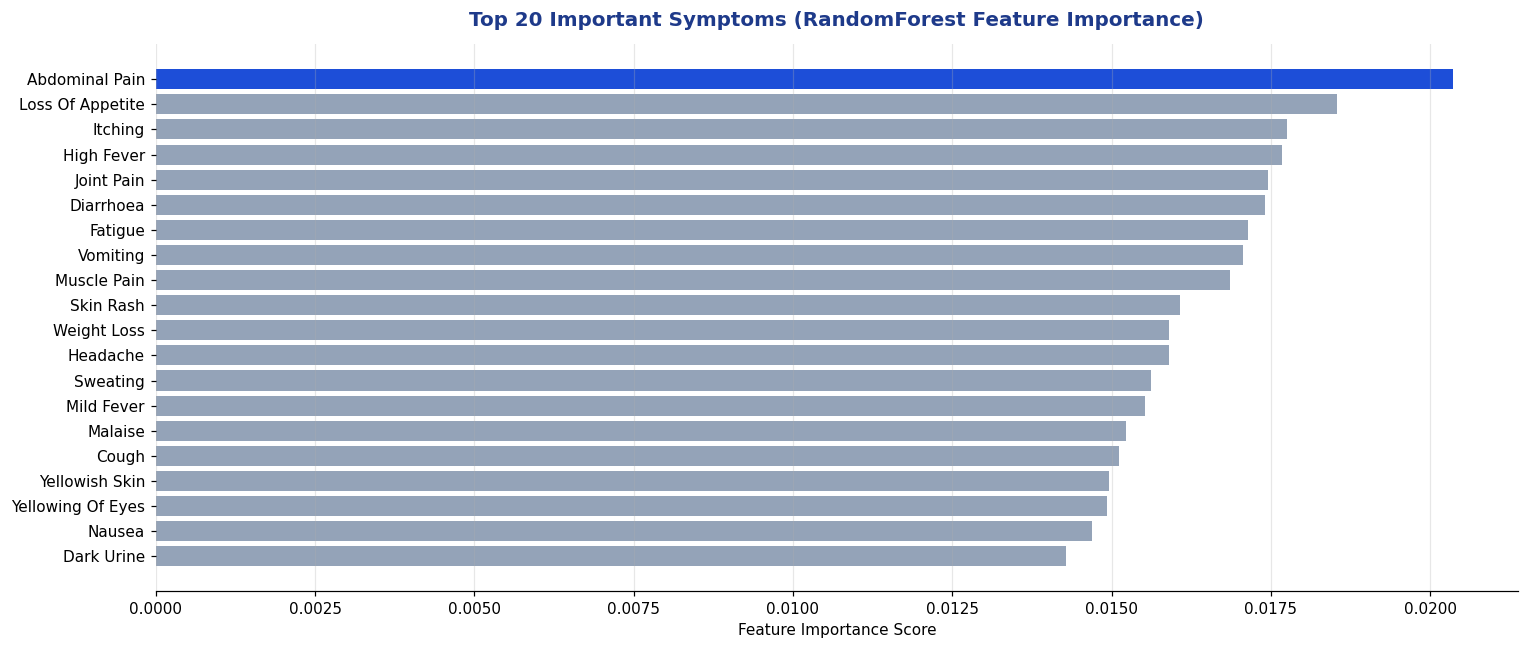

Top 10 most important symptoms:
  Abdominal Pain                       0.0204
  Loss Of Appetite                     0.0185
  Itching                              0.0177
  High Fever                           0.0177
  Joint Pain                           0.0175
  Diarrhoea                            0.0174
  Fatigue                              0.0171
  Vomiting                             0.0171
  Muscle Pain                          0.0169
  Skin Rash                            0.0161


In [10]:
rf = models["RandomForest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top20 = importances.head(20)
bar_colors = [RED if v > 0.04 else BLUE if v > 0.02 else "#94a3b8" for v in top20.values]
ax.barh(top20.index[::-1].str.replace("_", " ").str.title(),
        top20.values[::-1], color=bar_colors[::-1], edgecolor="none")
ax.set_title("Top 20 Important Symptoms (RandomForest Feature Importance)",
             fontsize=13, fontweight="bold", color="#1e3a8a", pad=12)
ax.set_xlabel("Feature Importance Score")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right","left"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "feature_importance.png"), bbox_inches="tight", dpi=130)
plt.show()
print("Top 10 most important symptoms:")
for s, v in importances.head(10).items():
    print(f"  {s.replace('_',' ').title():35s}  {v:.4f}")


---
## 9. 🌡️ Severity Scoring Validation

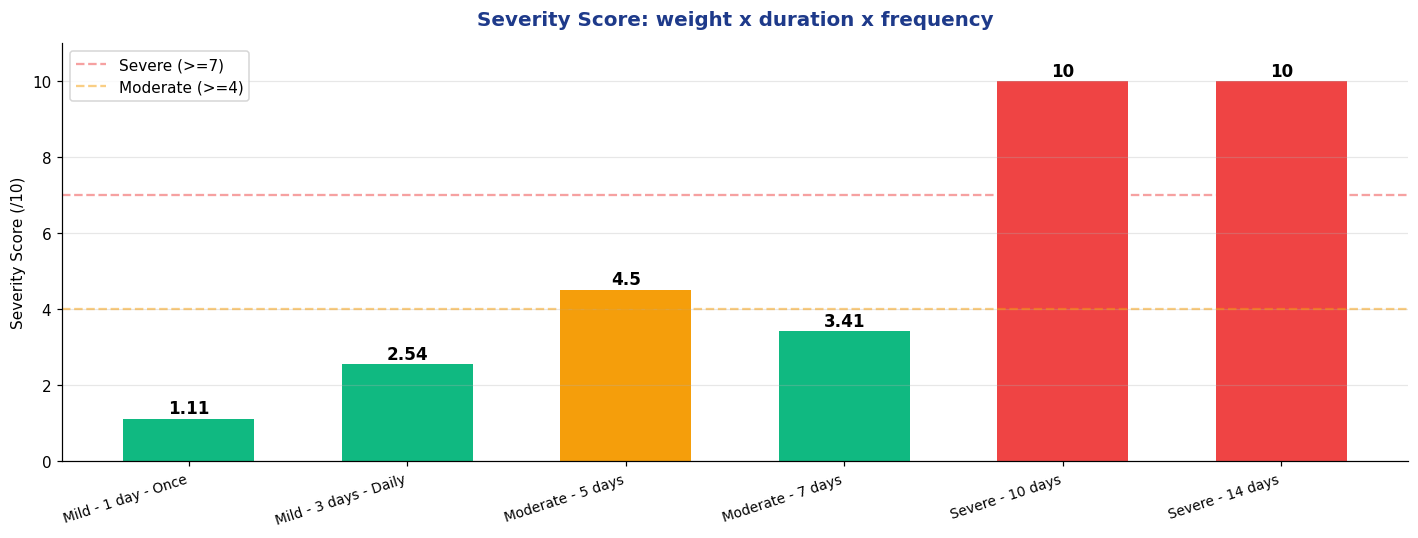

Severity scores:
  Mild - 1 day - Once             1.11  [MILD]
  Mild - 3 days - Daily           2.54  [MILD]
  Moderate - 5 days               4.50  [MODERATE]
  Moderate - 7 days               3.41  [MILD]
  Severe - 10 days                10.00  [SEVERE]
  Severe - 14 days                10.00  [SEVERE]


In [11]:
from utils.constants import SYMPTOM_WEIGHTS

scenarios = [
    ("Mild - 1 day - Once",       ["cough","runny_nose"], 1, 0.5),
    ("Mild - 3 days - Daily",     ["cough","runny_nose","headache"], 3, 1.0),
    ("Moderate - 5 days",         ["high_fever","headache","nausea","vomiting"], 5, 1.0),
    ("Moderate - 7 days",         ["joint_pain","fatigue","high_fever","diarrhoea"], 7, 1.0),
    ("Severe - 10 days",          ["chest_pain","breathlessness","fast_heart_rate","sweating"], 10, 1.5),
    ("Severe - 14 days",          ["chest_pain","breathlessness","altered_sensorium","coma"], 14, 1.5),
]

def calc_sev(syms, days, freq_f):
    raw = sum(SYMPTOM_WEIGHTS.get(s, 0.5) for s in syms)
    dur = min(1 + (days-1)*0.15, 3.0)
    mp  = max(len(syms)*1.0*3.0, 1)
    return round(min((raw*dur*freq_f/mp)*10, 10), 2)

labels = [s[0] for s in scenarios]
scores = [calc_sev(s[1], s[2], s[3]) for s in scenarios]
colors = [RED if sc>=7 else "#f59e0b" if sc>=4 else GREEN for sc in scores]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels, scores, color=colors, edgecolor="none", width=0.6)
for bar, sc in zip(bars, scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            str(sc), ha="center", fontweight="bold", fontsize=11)
ax.axhline(7, color=RED, linestyle="--", alpha=0.5, label="Severe (>=7)")
ax.axhline(4, color="#f59e0b", linestyle="--", alpha=0.5, label="Moderate (>=4)")
ax.set_ylim(0, 11)
ax.set_ylabel("Severity Score (/10)")
ax.set_title("Severity Score: weight x duration x frequency",
             fontsize=13, fontweight="bold", color="#1e3a8a", pad=12)
ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "severity_scoring.png"), bbox_inches="tight", dpi=130)
plt.show()
print("Severity scores:")
for l, s in zip(labels, scores):
    level = "SEVERE" if s>=7 else "MODERATE" if s>=4 else "MILD"
    print(f"  {l:30s}  {s:4.2f}  [{level}]")


---
## 10. 🧮 Per-Class Accuracy Analysis

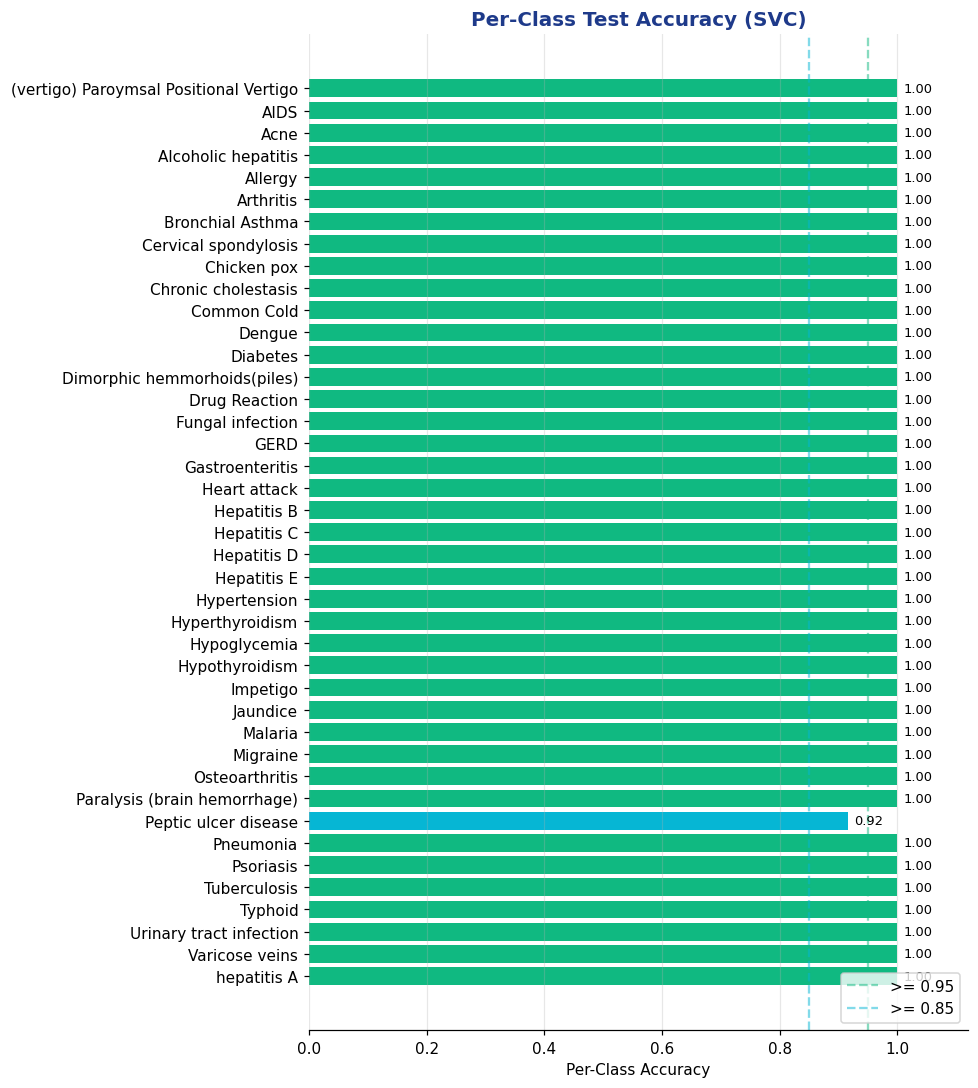

Overall Test Accuracy: 99.80%


In [12]:
y_pred = best_model.predict(X_test)
cm_mat = confusion_matrix(y_test, y_pred)
per_class_acc = cm_mat.diagonal() / cm_mat.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 10))
bar_colors = [GREEN if v >= 0.95 else TEAL if v >= 0.85 else RED for v in per_class_acc[::-1]]
ax.barh(le.classes_[::-1], per_class_acc[::-1], color=bar_colors, edgecolor="none")
ax.set_xlabel("Per-Class Accuracy")
ax.set_xlim(0, 1.12)
ax.set_title(f"Per-Class Test Accuracy ({best_name})", fontsize=13, fontweight="bold", color="#1e3a8a")
ax.axvline(0.95, color=GREEN, linestyle="--", alpha=0.5, label=">= 0.95")
ax.axvline(0.85, color=TEAL, linestyle="--", alpha=0.5, label=">= 0.85")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right","left"]].set_visible(False)
for i, (acc, cls) in enumerate(zip(per_class_acc[::-1], le.classes_[::-1])):
    ax.text(acc+0.01, i, f"{acc:.2f}", va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "images", "per_class_accuracy.png"), bbox_inches="tight", dpi=130)
plt.show()
print(f"Overall Test Accuracy: {best_model.score(X_test,y_test)*100:.2f}%")


---
## 11. 📝 Key Findings & Summary

In [13]:
import glob
print("=" * 65)
print("  MediSense AI v2.0 — Analysis Summary")
print("=" * 65)
print(f"  Dataset       : {len(df_bin):,} samples, {df_bin.shape[1]-1} features, {df_bin['Disease'].nunique()} diseases")
print(f"  Best Model    : {best_name}")
for n, r in cv_results.items():
    print(f"  {n:20s}: CV={r['mean']*100:.2f}% +/-{r['std']*100:.2f}%   Test={r['test']*100:.2f}%")
print()
sym_top = df_bin[[c for c in df_bin.columns if c != "Disease"]].sum().sort_values(ascending=False)
print("  Top 5 frequent symptoms:")
for s, v in sym_top.head(5).items():
    print(f"    {s.replace('_',' ').title():35s}: {v:,}")
print()
print("  Risk distribution:")
for r, c in df_desc["Risk_Level"].value_counts().items():
    print(f"    {r:10s}: {c} diseases")
print()
imgs = glob.glob(os.path.join(BASE, "images", "*.png"))
print(f"  Saved {len(imgs)} EDA plots to images/:")
for img in imgs:
    print(f"    {os.path.basename(img)}")
print()
print("  Run the app: streamlit run app.py")
print("=" * 65)


  MediSense AI v2.0 — Analysis Summary
  Dataset       : 4,920 samples, 132 features, 41 diseases
  Best Model    : SVC
  RandomForest        : CV=98.60% +/-0.47%   Test=98.68%
  SVC                 : CV=99.72% +/-0.17%   Test=99.80%

  Top 5 frequent symptoms:
    Fatigue                            : 1,628
    Vomiting                           : 1,517
    High Fever                         : 1,099
    Nausea                             : 936
    Loss Of Appetite                   : 927

  Risk distribution:
    Low       : 17 diseases
    High      : 13 diseases
    Medium    : 11 diseases

  Saved 8 EDA plots to images/:
    disease_distribution.png
    disease_symptom_heatmap.png
    feature_importance.png
    model_comparison.png
    per_class_accuracy.png
    severity_scoring.png
    symptom_frequency.png
    symptom_severity.png

  Run the app: streamlit run app.py
